In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "../data/train_FD001.txt"

df = pd.read_csv(file_path, sep=r"\s+", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

df.columns = columns

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
print("Dataset shape:", df.shape)
print("Number of engines:", df["engine_id"].nunique())
print("Missing values:", df.isnull().sum().sum())

Dataset shape: (20631, 26)
Number of engines: 100
Missing values: 0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


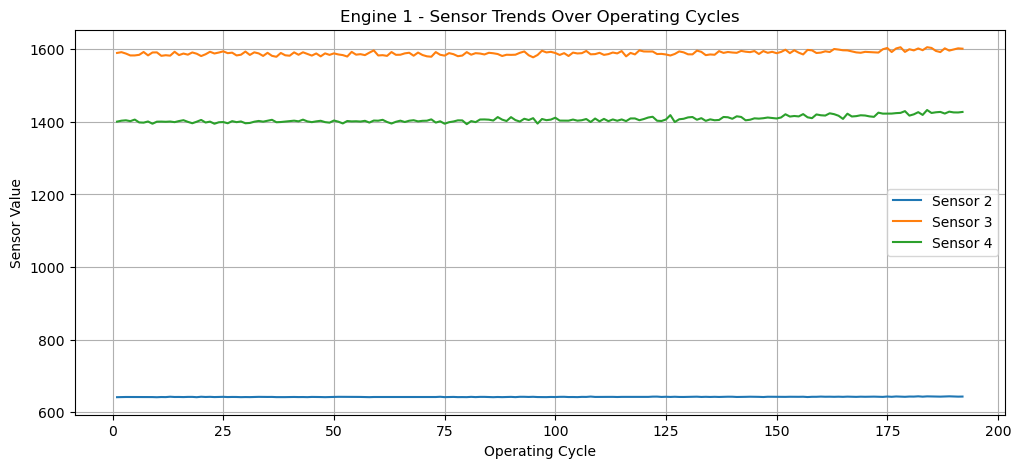

In [6]:
engine_1 = df[df["engine_id"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_2"],
    label="Sensor 2"
)

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_3"],
    label="Sensor 3"
)

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_4"],
    label="Sensor 4"
)

plt.xlabel("Operating Cycle")
plt.ylabel("Sensor Value")
plt.title("Engine 1 - Sensor Trends Over Operating Cycles")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

sensor_std = df[sensor_columns].std().sort_values()

sensor_std

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

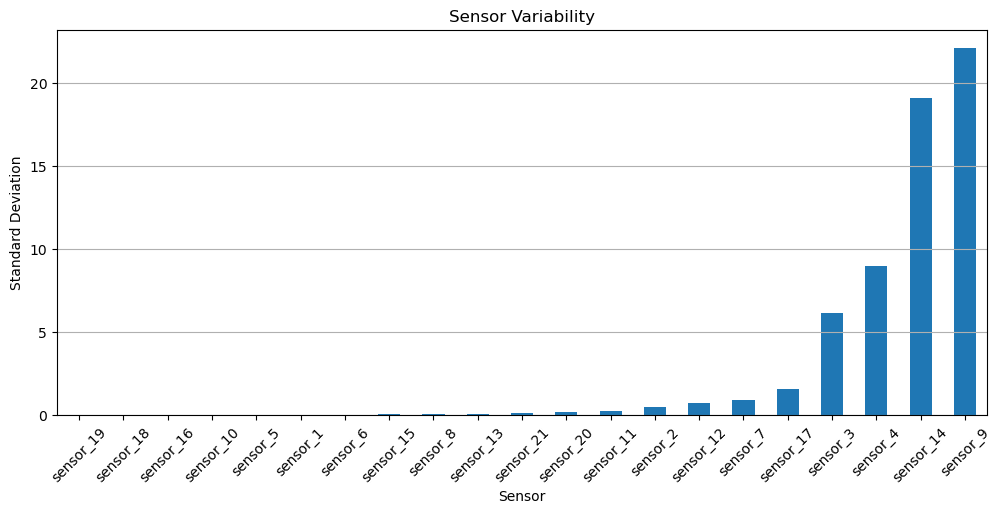

In [8]:
sensor_std.plot(kind="bar", figsize=(12, 5))

plt.title("Sensor Variability")
plt.xlabel("Sensor")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [9]:
max_cycle = df.groupby("engine_id")["cycle"].max()

df["RUL"] = df["engine_id"].map(max_cycle) - df["cycle"]

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [10]:
df[df["engine_id"] == 1][["engine_id", "cycle", "RUL"]].tail()

,engine_id,cycle,RUL
187,1,188,4
188,1,189,3
189,1,190,2
190,1,191,1
191,1,192,0


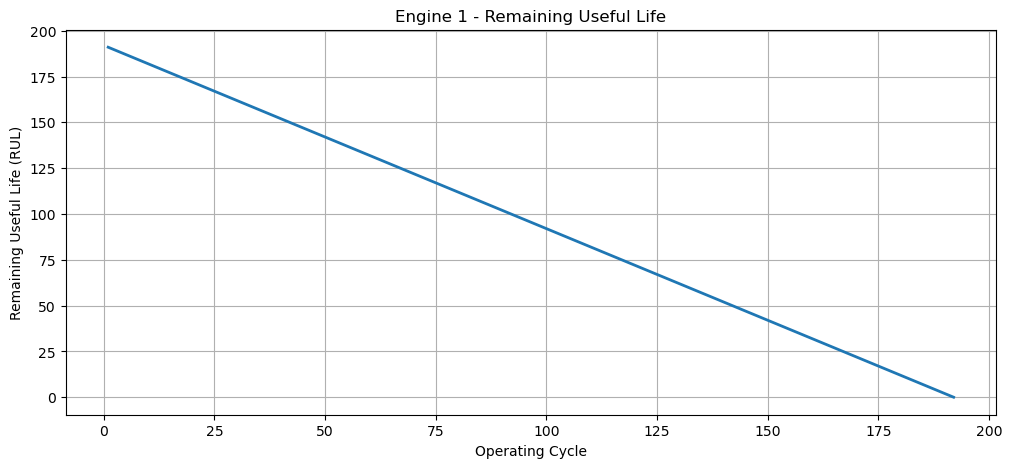

In [11]:
engine_1 = df[df["engine_id"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["RUL"],
    linewidth=2
)

plt.xlabel("Operating Cycle")
plt.ylabel("Remaining Useful Life (RUL)")
plt.title("Engine 1 - Remaining Useful Life")
plt.grid(True)

plt.show()

In [12]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

correlations = df[sensor_columns + ["RUL"]].corr()["RUL"].drop("RUL")

correlations = correlations.sort_values()

correlations

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64

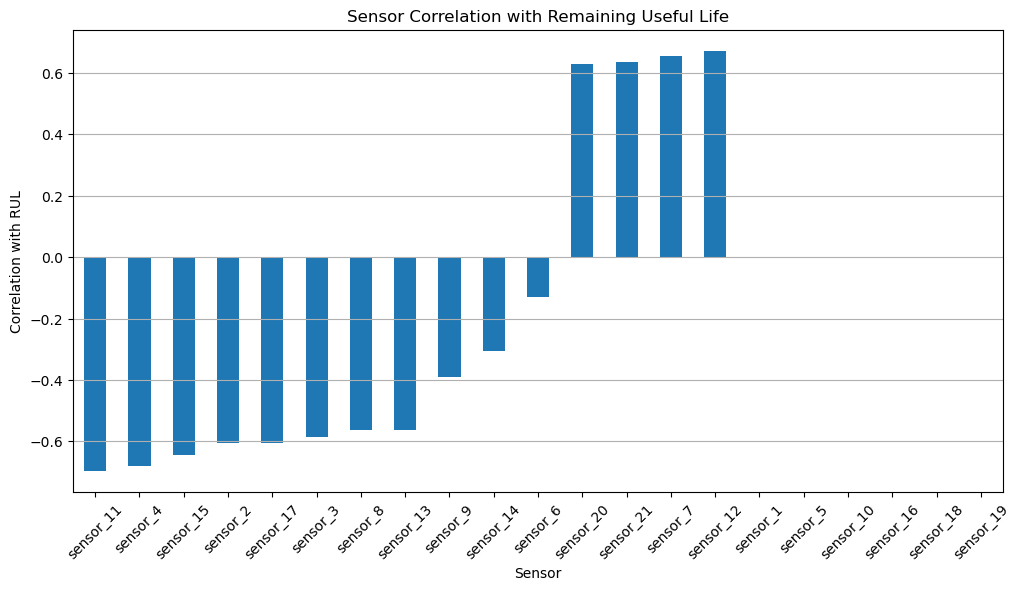

In [13]:
plt.figure(figsize=(12, 6))

correlations.plot(kind="bar")

plt.title("Sensor Correlation with Remaining Useful Life")
plt.xlabel("Sensor")
plt.ylabel("Correlation with RUL")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [14]:
## Step 10 — Select our initial sensor features
# Let's create a list of sensors with a reasonably strong relationship to RUL.

selected_sensors = correlations[correlations.abs() >= 0.5].index.tolist()

print("Selected sensors:")
print(selected_sensors)
print("Number of selected sensors:", len(selected_sensors))

Selected sensors:
['sensor_11', 'sensor_4', 'sensor_15', 'sensor_2', 'sensor_17', 'sensor_3', 'sensor_8', 'sensor_13', 'sensor_20', 'sensor_21', 'sensor_7', 'sensor_12']
Number of selected sensors: 12


In [15]:
# Next: prepare the ML dataset
# Now we're going to separate:
     # X = sensor measurements/features
     # y = RUL, the value we want the model to predict

X = df[selected_sensors]
y = df["RUL"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20631, 12)
Target shape: (20631,)


In [16]:
## Now we're ready for our first machine-learning model.
#Split the data
  #Before training, we need to keep some data aside to test whether the model works on data it hasn't seen.
 
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_val.shape)

#We're doing an 80/20 split:
   
   #20,631 total records ---> # 80% → Training data → model learns,# 20% → Validation data → model gets tested

Training features: (16504, 12)
Validation features: (4127, 12)
Training target: (16504,)
Validation target: (4127,)


In [17]:
## Train a Random Forest model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")


Random Forest model trained successfully!


In [18]:
# How good is our model at predicting RUL?
# Make predictions

y_pred = rf_model.predict(X_val)

print("First 10 actual RUL values:")
print(y_val.head(10).values)

print("\nFirst 10 predicted RUL values:")
print(y_pred[:10])

First 10 actual RUL values:
[135   2 217   0 178  70  87  87  73  77]

First 10 predicted RUL values:
[123.73   9.69 188.57   2.03 163.12 110.22 130.21  67.34 135.37 143.42]


In [19]:
# Evaluate the Random Forest

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f"MAE:  {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")
print(f"R²:   {r2:.3f}")

MAE:  33.67 cycles
RMSE: 45.29 cycles
R²:   0.551


In [20]:
# Our next step is feature engineering. We’ll add information about recent sensor behavior rather than using only the current sensor reading.
# Create sensor trend features

# Create a copy so we don't modify the original dataset
df_ml = df.copy()

# Sort by engine and operating cycle
df_ml = df_ml.sort_values(["engine_id", "cycle"])

# Sensors selected earlier
selected_sensors = correlations[correlations.abs() >= 0.5].index.tolist()

# Create rolling mean features
for sensor in selected_sensors:
    df_ml[f"{sensor}_rolling_mean"] = (
        df_ml.groupby("engine_id")[sensor]
        .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    )

print("New dataset shape:", df_ml.shape)


New dataset shape: (20631, 39)


In [21]:
# Split by engine
# For a proper predictive-maintenance project, we'll make the validation split by engine, not randomly by individual rows.

from sklearn.model_selection import train_test_split

engine_ids = df_ml["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = df_ml[df_ml["engine_id"].isin(train_engines)]
val_df = df_ml[df_ml["engine_id"].isin(val_engines)]

print("Training engines:", len(train_engines))
print("Validation engines:", len(val_engines))
print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))

Training engines: 80
Validation engines: 20
Training rows: 16561
Validation rows: 4070


In [22]:
#Prepare the improved features
#Now we'll tell the model which columns to use.

feature_columns = selected_sensors.copy()

for sensor in selected_sensors:
    feature_columns.append(f"{sensor}_rolling_mean")

X_train = train_df[feature_columns]
y_train = train_df["RUL"]

X_val = val_df[feature_columns]
y_val = val_df["RUL"]

print("Number of features:", len(feature_columns))
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Number of features: 24
Training shape: (16561, 24)
Validation shape: (4070, 24)


In [23]:
# Train the improved model

rf_improved = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_improved.fit(X_train, y_train)

print("Improved Random Forest model trained successfully!")

Improved Random Forest model trained successfully!


In [24]:
y_pred_improved = rf_improved.predict(X_val)

mae_improved = mean_absolute_error(y_val, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_val, y_pred_improved))
r2_improved = r2_score(y_val, y_pred_improved)

print(f"Improved MAE:  {mae_improved:.2f} cycles")
print(f"Improved RMSE: {rmse_improved:.2f} cycles")
print(f"Improved R²:   {r2_improved:.3f}")

Improved MAE:  26.53 cycles
Improved RMSE: 36.15 cycles
Improved R²:   0.697


In [25]:
# Test different rolling-window sizes

windows = [5, 10, 20]

for window in windows:
    for sensor in selected_sensors:
        df_ml[f"{sensor}_rolling_{window}"] = (
            df_ml.groupby("engine_id")[sensor]
            .transform(
                lambda x: x.rolling(window=window, min_periods=1).mean()
            )
        )

print("Feature engineering completed.")

Feature engineering completed.


In [26]:
# Create the new feature set (Commented this code for future references)

#feature_columns = selected_sensors.copy()

#for window in [5, 10, 20]:
    #for sensor in selected_sensors:
        #feature_columns.append(f"{sensor}_rolling_{window}")

#X_train = train_df[feature_columns]
#y_train = train_df["RUL"]

#X_val = val_df[feature_columns]
#y_val = val_df["RUL"]

#print("Number of features:", len(feature_columns))
#print("Training shape:", X_train.shape)
#print("Validation shape:", X_val.shape)

In [27]:
# Recreate train and validation datasets
train_df = df_ml[df_ml["engine_id"].isin(train_engines)].copy()
val_df = df_ml[df_ml["engine_id"].isin(val_engines)].copy()

# Create feature list
feature_columns = selected_sensors.copy()

for window in [5, 10, 20]:
    for sensor in selected_sensors:
        feature_columns.append(f"{sensor}_rolling_{window}")

# Prepare X and y
X_train = train_df[feature_columns]
y_train = train_df["RUL"]

X_val = val_df[feature_columns]
y_val = val_df["RUL"]

print("Number of features:", len(feature_columns))
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Number of features: 48
Training shape: (16561, 48)
Validation shape: (4070, 48)


In [28]:
# rain the 48-feature Random Forest

rf_48 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_48.fit(X_train, y_train)

print("48-feature Random Forest trained successfully!")

48-feature Random Forest trained successfully!


In [29]:
y_pred_48 = rf_48.predict(X_val)

mae_48 = mean_absolute_error(y_val, y_pred_48)
rmse_48 = np.sqrt(mean_squared_error(y_val, y_pred_48))
r2_48 = r2_score(y_val, y_pred_48)

print(f"48-feature MAE:  {mae_48:.2f} cycles")
print(f"48-feature RMSE: {rmse_48:.2f} cycles")
print(f"48-feature R²:   {r2_48:.3f}")

48-feature MAE:  24.41 cycles
48-feature RMSE: 33.81 cycles
48-feature R²:   0.735


In [30]:
# My model now explains about 73.5% of the variation in RUL on our engine-level validation set.

# That's a much stronger result.

#More importantly, I can explain WHY

##My project isn't just:

#"I trained Random Forest and got 73.5%."

#I've demonstrated an engineering/data-science process:

#Raw sensor data

#→ identified useful sensors
#→ calculated RUL
#→ analyzed sensor/RUL relationships
#→ created time-series features
#→ captured short-, medium-, and longer-term sensor behavior
#→ trained models
#→ compared performance
#→ selected the better feature configuration



In [31]:
# Try Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")


Gradient Boosting model trained successfully!


In [32]:
y_pred_gb = gb_model.predict(X_val)

mae_gb = mean_absolute_error(y_val, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_val, y_pred_gb))
r2_gb = r2_score(y_val, y_pred_gb)

print(f"Gradient Boosting MAE:  {mae_gb:.2f} cycles")
print(f"Gradient Boosting RMSE: {rmse_gb:.2f} cycles")
print(f"Gradient Boosting R²:   {r2_gb:.3f}")

Gradient Boosting MAE:  24.13 cycles
Gradient Boosting RMSE: 32.79 cycles
Gradient Boosting R²:   0.751


In [33]:
# Load the test dataset

test_file_path = "../data/test_FD001.txt"

test_df = pd.read_csv(
    test_file_path,
    sep=r"\s+",
    header=None
)

test_df.columns = columns

print("Test dataset shape:", test_df.shape)
test_df.head()


Test dataset shape: (13096, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [34]:
# Then load the actual RUL values

rul_file_path = "../data/RUL_FD001.txt"

true_rul = pd.read_csv(
    rul_file_path,
    sep=r"\s+",
    header=None
)

true_rul.columns = ["RUL"]

print("Number of test engines:", len(true_rul))
true_rul.head()


Number of test engines: 100


,RUL
0,112
1,98
2,69
3,82
4,91


In [35]:
         # Create test rolling features

# Sort test data by engine and cycle
test_df = test_df.sort_values(["engine_id", "cycle"]).copy()

# Create rolling features
for window in [5, 10, 20]:
    for sensor in selected_sensors:
        test_df[f"{sensor}_rolling_{window}"] = (
            test_df.groupby("engine_id")[sensor]
            .transform(
                lambda x: x.rolling(window=window, min_periods=1).mean()
            )
        )

print("Test feature engineering completed.")
print("Test dataset shape:", test_df.shape)

Test feature engineering completed.
Test dataset shape: (13096, 62)


In [36]:
# Get the final observation for each engine

test_last = (
    test_df
    .groupby("engine_id")
    .tail(1)
    .sort_values("engine_id")
)

X_test = test_last[feature_columns]

print("Test engines:", test_last["engine_id"].nunique())
print("Test feature shape:", X_test.shape)

Test engines: 100
Test feature shape: (100, 48)


In [37]:
# Make the final predictions

# Predict RUL for the 100 unseen test engines
y_test_pred = gb_model.predict(X_test)

print("First 10 predicted RUL values:")
print(y_test_pred[:10])

print("\nFirst 10 actual RUL values:")
print(true_rul["RUL"].values[:10])

First 10 predicted RUL values:
[188.11030773 158.09905125  57.79884431  89.9620566  123.88391994
 144.31015865 101.2777634  123.35797869 151.94419586 120.33200621]

First 10 actual RUL values:
[112  98  69  82  91  93  91  95 111  96]


In [38]:
# Then calculate the final test performance

mae_test = mean_absolute_error(true_rul["RUL"], y_test_pred)
rmse_test = np.sqrt(mean_squared_error(true_rul["RUL"], y_test_pred))
r2_test = r2_score(true_rul["RUL"], y_test_pred)

print(f"Final Test MAE:  {mae_test:.2f} cycles")
print(f"Final Test RMSE: {rmse_test:.2f} cycles")
print(f"Final Test R²:   {r2_test:.3f}")

Final Test MAE:  24.16 cycles
Final Test RMSE: 32.28 cycles
Final Test R²:   0.396


In [39]:
# Create prediction results for Power BI

prediction_results = pd.DataFrame({
    "engine_id": range(1, len(y_test_pred) + 1),
    "actual_rul": true_rul["RUL"].values,
    "predicted_rul": y_test_pred
})

prediction_results["absolute_error"] = (
    prediction_results["actual_rul"] -
    prediction_results["predicted_rul"]
).abs()

prediction_results.head(10)

,engine_id,actual_rul,predicted_rul,absolute_error
0,1,112,188.110308,76.110308
1,2,98,158.099051,60.099051
2,3,69,57.798844,11.201156
3,4,82,89.962057,7.962057
4,5,91,123.883920,32.883920
5,6,93,144.310159,51.310159
6,7,91,101.277763,10.277763
7,8,95,123.357979,28.357979
8,9,111,151.944196,40.944196
9,10,96,120.332006,24.332006


In [40]:
# Save model predictions for Power BI

prediction_results.to_csv(
    r"D:\Aircraft_Engine_RUL_Prediction\data\rul_predictions.csv",
    index=False
)

print("CSV saved successfully!")

CSV saved successfully!


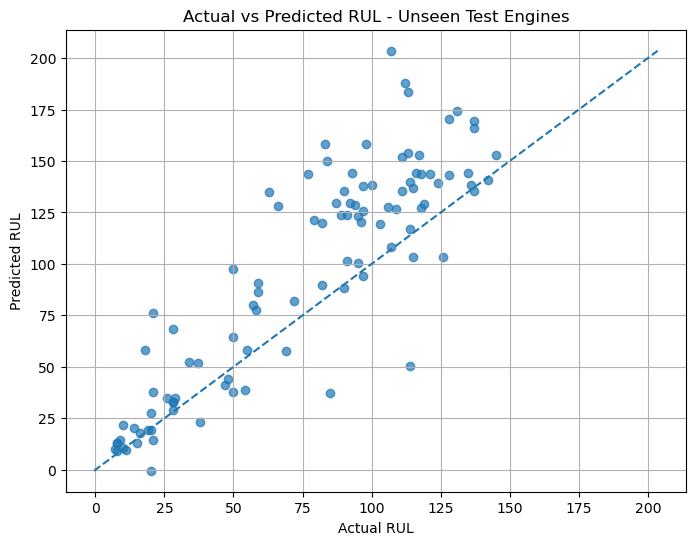

In [41]:
# Let's create an Actual vs Predicted RUL plot.

plt.figure(figsize=(8, 6))

plt.scatter(
    true_rul["RUL"],
    y_test_pred,
    alpha=0.7
)

# Perfect prediction line
min_rul = min(true_rul["RUL"].min(), y_test_pred.min())
max_rul = max(true_rul["RUL"].max(), y_test_pred.max())

plt.plot(
    [min_rul, max_rul],
    [min_rul, max_rul],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL - Unseen Test Engines")
plt.grid(True)
plt.show()

In [42]:
# let's investigate which features the Gradient Boosting model considers most important.
feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

print(feature_importance.head(15))

sensor_4_rolling_5      0.151079
sensor_4_rolling_10     0.105506
sensor_21_rolling_10    0.098045
sensor_11_rolling_5     0.079050
sensor_15_rolling_10    0.073996
sensor_17_rolling_10    0.067812
sensor_13_rolling_20    0.053625
sensor_3_rolling_10     0.040652
sensor_8_rolling_20     0.039725
sensor_15_rolling_5     0.038956
sensor_21_rolling_5     0.030363
sensor_20_rolling_10    0.025001
sensor_2_rolling_10     0.024809
sensor_2_rolling_5      0.017826
sensor_3_rolling_20     0.016244
dtype: float64


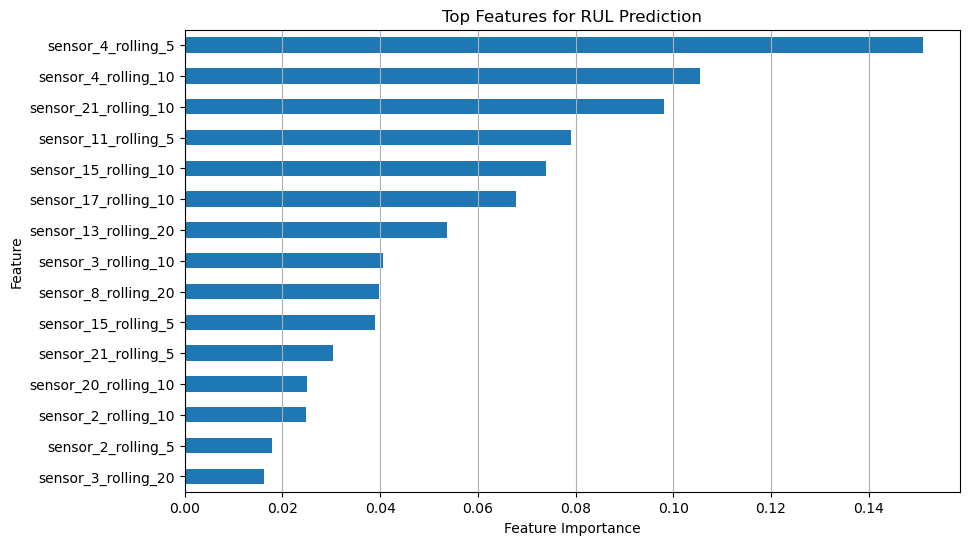

In [43]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features for RUL Prediction")
plt.grid(axis="x")

plt.show()